# 05.07 - Image I/O for CV

**Daily output:** a reliable `safe_image_loader()` function.

Today is about the quiet part of CV that can silently ruin a model: image loading. You will practice PIL vs OpenCV, RGB/BGR, grayscale and alpha channels, dtype and value range, resizing, aspect ratio, corrupt file handling, and the final HWC/CHW shape contract.

Masterplan resources: Pillow Handbook, OpenCV Tutorials, Kaggle Computer Vision.

**Notebook type:** Practice notebook with theory, exercises, and TODO cells.


## Mental Model

PIL/Pillow loads images as `PIL.Image.Image` objects. For color images, `img.convert("RGB")` gives predictable RGB data, and `np.array(img)` gives `[H, W, C]`.

OpenCV loads images as NumPy arrays. `cv2.imread(path)` returns BGR by default and returns `None` if reading fails. Before plotting or feeding a model that expects RGB, convert with `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

A strong contest pipeline forces a contract:

- color: RGB
- image array while inspecting: `[H, W, C]`
- tensor before PyTorch model: `[C, H, W]`
- dtype before model: `float32`
- value range before model: usually `[0, 1]`, then optional mean/std normalization


In [2]:
from pathlib import Path
import random

import numpy as np
from PIL import Image, ImageOps, UnidentifiedImageError

try:
    import cv2
except ImportError:
    cv2 = None
    print("OpenCV is not installed. OpenCV examples will be skipped.")

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib is not installed. Visualization examples will be skipped.")

random.seed(42)
np.random.seed(42)

ROOT = Path("_day05_demo_images")
ROOT.mkdir(exist_ok=True)


In [3]:
def make_demo_images(root=ROOT):
    h, w = 96, 128
    y = np.linspace(0, 255, h, dtype=np.uint8)[:, None]
    x = np.linspace(0, 255, w, dtype=np.uint8)[None, :]

    red = np.repeat(x, h, axis=0)
    green = np.repeat(y, w, axis=1)
    blue = np.full((h, w), 80, dtype=np.uint8)
    rgb = np.stack([red, green, blue], axis=-1)
    Image.fromarray(rgb, mode="RGB").save(root / "rgb_gradient.png")

    checker = (((np.indices((80, 80)).sum(axis=0) // 10) % 2) * 255).astype(np.uint8)
    checker_rgb = np.stack([checker, np.zeros_like(checker), 255 - checker], axis=-1)
    Image.fromarray(checker_rgb, mode="RGB").save(root / "checker.jpg", quality=95)

    gray = np.tile(np.linspace(0, 255, 100, dtype=np.uint8), (60, 1))
    Image.fromarray(gray, mode="L").save(root / "grayscale.png")

    rgba = np.zeros((70, 110, 4), dtype=np.uint8)
    rgba[..., 0] = 255
    rgba[..., 1] = 180
    rgba[..., 3] = np.linspace(30, 255, 110, dtype=np.uint8)[None, :]
    Image.fromarray(rgba, mode="RGBA").save(root / "rgba.png")

    (root / "corrupt.jpg").write_bytes(b"this is not a valid image file")

make_demo_images()
sorted(p.name for p in ROOT.iterdir())


C:\Users\Dell\AppData\Local\Temp\ipykernel_29288\1049061749.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(rgb, mode="RGB").save(root / "rgb_gradient.png")
C:\Users\Dell\AppData\Local\Temp\ipykernel_29288\1049061749.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(checker_rgb, mode="RGB").save(root / "checker.jpg", quality=95)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29288\1049061749.py:17: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(gray, mode="L").save(root / "grayscale.png")
C:\Users\Dell\AppData\Local\Temp\ipykernel_29288\1049061749.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(rgba, mode="RGBA").save(root / "rgba.png")


['checker.jpg', 'corrupt.jpg', 'grayscale.png', 'rgb_gradient.png', 'rgba.png']

## Inspect Image Data

When debugging input, print mode, shape, dtype, min/max, and a sample pixel. Most image bugs become obvious after those checks.


In [10]:
# TODO 05-A: Inspect image data.
# Write describe_array(name, arr), then compare:
# 1. PIL Image.open(...), np.array(...)
# 2. OpenCV cv2.imread(...)
# 3. OpenCV BGR converted to RGB
#
# Expected checks: shape, dtype, min, max, first pixel.

def describe_array(name, arr):
    print(arr.shape)
    print(arr.dtype)
    print(arr.min,arr.max)
    print(arr[0,0])
    print()

image_path = ROOT / "rgb_gradient.png"
img_PIL = Image.open(image_path).convert("RGB")
describe_array(None,np.array(img_PIL))
img_cv2 = cv2.imread(image_path)
describe_array(None,img_cv2)
img_cv2 = cv2.cvtColor(img_cv2,cv2.COLOR_BGR2RGB)
describe_array(None,img_cv2)
# TODO: load with PIL and inspect.
# TODO: if cv2 is available, load with OpenCV, convert BGR to RGB, and compare.


(96, 128, 3)
uint8
<built-in method min of numpy.ndarray object at 0x0000020FF4A632D0> <built-in method max of numpy.ndarray object at 0x0000020FF4A632D0>
[ 0  0 80]

(96, 128, 3)
uint8
<built-in method min of numpy.ndarray object at 0x0000020FF4A632D0> <built-in method max of numpy.ndarray object at 0x0000020FF4A632D0>
[80  0  0]

(96, 128, 3)
uint8
<built-in method min of numpy.ndarray object at 0x0000020FF4683CF0> <built-in method max of numpy.ndarray object at 0x0000020FF4683CF0>
[ 0  0 80]



## RGB vs BGR

If a red object appears blue, suspect channel order. OpenCV's BGR output must be converted before plotting or mixing with PIL/torchvision-style RGB transforms.


(np.float64(-0.5), np.float64(79.5), np.float64(79.5), np.float64(-0.5))

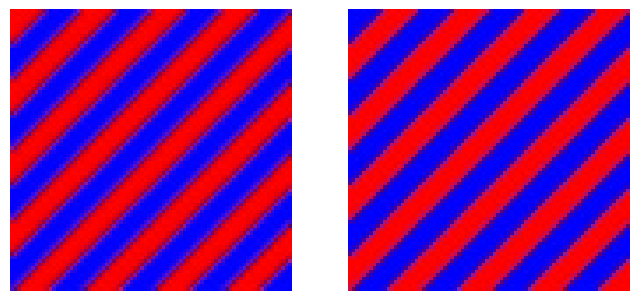

In [18]:
# TODO 05-B: RGB vs BGR visualization.
# If cv2 and matplotlib are installed:
# 1. Load checker.jpg with cv2.imread.
# 2. Plot the raw BGR array.
# 3. Convert BGR -> RGB and plot again.
# 4. Explain why the first plot has wrong colors.

fig,axes = plt.subplots(1,2,figsize = (8,4))

img = cv2.imread(ROOT / "checker.jpg")
axes[0].imshow(img)
axes[0].axis("off")

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
axes[1].imshow(img)
axes[1].axis("off")



## Grayscale and Alpha Channels

Real datasets can contain grayscale (`L`) or transparent (`RGBA`) images. Use `convert("RGB")` when the model expects exactly three channels.


In [26]:
# TODO 05-C: Grayscale and alpha handling.
# For grayscale.png and rgba.png:
# 1. Print PIL mode.
# 2. Print np.array(img).shape.
# 3. Convert to RGB and print the new shape.

for path in [ROOT / "grayscale.png", ROOT / "rgba.png"]:
    img = Image.open(path)
    print(img.mode)
    print(np.array(img).shape)
    img = img.convert("RGB")
    print(np.array(img).shape)


L
(60, 100)
(60, 100, 3)
RGBA
(70, 110, 4)
(70, 110, 3)


## Resizing Choices

Direct resize is fast and simple, but it can distort aspect ratio. Aspect-ratio resize plus padding preserves geometry but adds borders. For quick baselines, direct resize is often acceptable; for objects, documents, video frames, or medical-like data, padding is often safer.


In [35]:
# TODO 05-D: Resize policies.
# Implement:
# - resize_stretch(img, size)
# - resize_keep_aspect_and_pad(img, size, fill)
#
# Then test both on rgb_gradient.png and print sizes.

def resize_stretch(img, size=(224, 224)):
    img = img.resize(size)
    return img

def resize_keep_aspect_and_pad(img, size=(224, 224), fill=(0, 0, 0)):
    img.thumbnail(size,Image.Resampling.LANCZOS)
    new_img = Image.new("RGB",size,fill)
    width = (size[0] - img.width)//2
    height = (size[1] - img.height)//2
    new_img.paste(img,(width,height))
    return new_img

sample = Image.open(ROOT / "rgb_gradient.png").convert("RGB")
print(sample)
sample = resize_stretch(sample)
print(sample)
sample = resize_keep_aspect_and_pad(sample)
print(sample)
# TODO: print original, stretched, and padded sizes.


<PIL.Image.Image image mode=RGB size=128x96 at 0x20FF495C050>
<PIL.Image.Image image mode=RGB size=224x224 at 0x20FF4ACE5D0>
<PIL.Image.Image image mode=RGB size=224x224 at 0x20FF4ACE990>


## Daily Output: `safe_image_loader()`

This loader catches missing/corrupt files, fixes EXIF orientation, converts to RGB, optionally resizes, and returns either PIL, HWC uint8, or CHW float32.


In [77]:
# TODO 05-E: Daily output.
# Implement safe_image_loader().
#
# Requirements:
# - accept str or Path
# - fix EXIF orientation with ImageOps.exif_transpose
# - convert every image to RGB
# - optionally resize
# - support output="pil", "hwc_uint8", "chw_float32", "bgr_uint8"
# - if strict=False, return None and print a warning on bad files
# - if strict=True, raise the original error

def safe_image_loader(path, size=None, keep_aspect=False, output="pil", strict=False, fill=(0, 0, 0)):
    if strict == False : 
        try : 
            image = Image.open(path)
            image = ImageOps.exif_transpose(image)
            image = image.convert("RGB")
            if size != None : 
                if keep_aspect == False : 
                    image = resize_stretch(image,size)
                else : image = resize_keep_aspect_and_pad(image,size,fill)
            if output == "pil" : return image
            elif output == "hwc_uint8" : return np.array(image)
            elif output == "chw_float32" :
                image = np.array(image)/256
                image = np.transpose(image,(2,0,1)).astype(np.float32)
                return image
            else :
                image = np.array(image)
                image = image[:,:,::-1]
                return image
        except :
            return None
    else : 
        image = Image.open(path)
        image.verify()
        image = ImageOps.exif_transpose(image)
        image = image.convert("RGB")
        if size != None : 
            if keep_aspect == false : 
                image = resize_stretch(image,size)
            else : image = resize_keep_aspect_and_pad(image,size,fill)
        if output == "pil" : return image
        elif output == "hwc_uint8" : return np.array(image)
        elif output == "chw_float32" :
            image = np.array(image)
            image = np.transpose(image,(2,0,1)).astype(np.float32)
            return image
        else :
            image = image.convert("BGR")
            return np.array(image)
    

x = safe_image_loader(ROOT / "rgba.png", size=(32, 32), output="bgr_uint8")
print(x)
# TODO: test on rgba.png and corrupt.jpg.


[[[  0 180 255]
  [  0 180 255]
  [  0 180 255]
  ...
  [  0 180 255]
  [  0 180 255]
  [  0 180 255]]

 [[  0 180 255]
  [  0 180 255]
  [  0 180 255]
  ...
  [  0 180 255]
  [  0 180 255]
  [  0 180 255]]

 [[  0 180 255]
  [  0 180 255]
  [  0 180 255]
  ...
  [  0 180 255]
  [  0 180 255]
  [  0 180 255]]

 ...

 [[  0 180 255]
  [  0 180 255]
  [  0 180 255]
  ...
  [  0 180 255]
  [  0 180 255]
  [  0 180 255]]

 [[  0 180 255]
  [  0 180 255]
  [  0 180 255]
  ...
  [  0 180 255]
  [  0 180 255]
  [  0 180 255]]

 [[  0 180 255]
  [  0 180 255]
  [  0 180 255]
  ...
  [  0 180 255]
  [  0 180 255]
  [  0 180 255]]]


## Folder Scan

Before training, scan the folder once. Count good files, bad files, image modes, and dimensions. This catches bad paths and weird channels early.


In [51]:
import os
# TODO 05-F: Folder scan.
# Implement scan_image_folder(root).
#
# Return a list of dicts with:
# path, ok, mode, width, height

def scan_image_folder(root):
    scan = []
    for files in os.listdir(root) : 
        res = {}
        path = os.path.join(root,files)
        try : 
            img = Image.open(path)
            img.verify()
            ok = True
        except : 
            ok = False
        if not ok : 
            mode = None
            width = None
            height = None
        else : 
            mode = img.mode
            width = img.width
            height = img.height
        res["path"] = path
        res["ok"] = ok
        res["mode"] = mode
        res["height"] = height
        res["width"] = width
        scan.append(res)
    return scan

# TODO: print each row from scan_image_folder(ROOT).
scan = scan_image_folder(ROOT)
for i in scan : 
    print(i)

{'path': '_day05_demo_images\\checker.jpg', 'ok': True, 'mode': 'RGB', 'height': 80, 'width': 80}
{'path': '_day05_demo_images\\corrupt.jpg', 'ok': False, 'mode': None, 'height': None, 'width': None}
{'path': '_day05_demo_images\\grayscale.png', 'ok': True, 'mode': 'L', 'height': 60, 'width': 100}
{'path': '_day05_demo_images\\rgba.png', 'ok': True, 'mode': 'RGBA', 'height': 70, 'width': 110}
{'path': '_day05_demo_images\\rgb_gradient.png', 'ok': True, 'mode': 'RGB', 'height': 96, 'width': 128}


## Day 05 Checklist

Verify path exists, image decodes, color is RGB, shape is expected, dtype is expected, value range is expected, train/validation preprocessing is intentional, and corrupt files have a defined policy: skip, placeholder, or fail fast.


## Test Cases

Run this cell after completing the TODO cells above. A correct implementation should print `Day 05 tests passed`.


In [78]:
def run_day05_tests():
    required_names = [
        "resize_stretch",
        "resize_keep_aspect_and_pad",
        "safe_image_loader",
        "scan_image_folder",
    ]
    for name in required_names:
        assert name in globals(), f"Missing function: {name}"
        assert callable(globals()[name]), f"{name} must be callable"

    sample = Image.open(ROOT / "rgb_gradient.png").convert("RGB")
    assert resize_stretch(sample, (32, 32)).size == (32, 32)
    assert resize_keep_aspect_and_pad(sample, (32, 32)).size == (32, 32)

    x = safe_image_loader(ROOT / "rgba.png", size=(32, 32), output="chw_float32")
    assert x is not None, "safe_image_loader returned None for a valid image"
    assert x.shape == (3, 32, 32), f"Expected CHW shape (3, 32, 32), got {x.shape}"
    assert x.dtype == np.float32, f"Expected float32, got {x.dtype}"
    assert 0.0 <= float(x.min()) <= float(x.max()) <= 1.0

    hwc = safe_image_loader(ROOT / "grayscale.png", size=(16, 16), output="hwc_uint8")
    assert hwc.shape == (16, 16, 3), f"Grayscale images must become RGB, got {hwc.shape}"
    assert hwc.dtype == np.uint8

    bgr = safe_image_loader(ROOT / "rgb_gradient.png", size=(16, 16), output="bgr_uint8")
    rgb = safe_image_loader(ROOT / "rgb_gradient.png", size=(16, 16), output="hwc_uint8")
    assert np.array_equal(bgr[..., ::-1], rgb), "BGR output should reverse RGB channel order"

    bad = safe_image_loader(ROOT / "corrupt.jpg", size=(16, 16), output="chw_float32", strict=False)
    assert bad is None, "Corrupt image should return None when strict=False"

    scan = scan_image_folder(ROOT)
    assert isinstance(scan, list) and len(scan) >= 5
    corrupt_rows = [row for row in scan if str(row["path"]).endswith("corrupt.jpg")]
    assert corrupt_rows and corrupt_rows[0]["ok"] is False

    print("Day 05 tests passed")

run_day05_tests()


Day 05 tests passed
